In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import cv2

# Load CSVs
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(train_df.head())
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

# Load a sample image
sample_id = train_df.iloc[0]["Id"]
sample_label = train_df.iloc[0]["Category"]
img_path = Path(f"train/train/{sample_label}/{sample_id}.png")

      Id  Category
0   7168         6
1   9876         3
2  78117         6
3   9626         1
4  29492         3
Train size: 17000, Test size: 3000


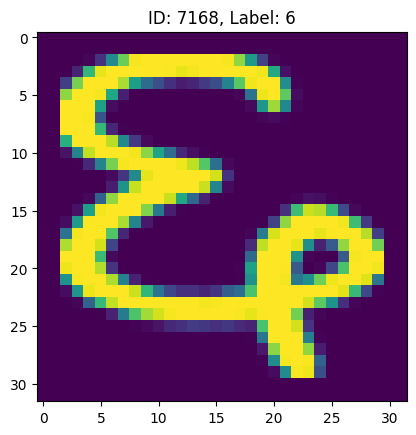

In [2]:
# view original image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"ID: {sample_id}, Label: {sample_label}")
plt.show()

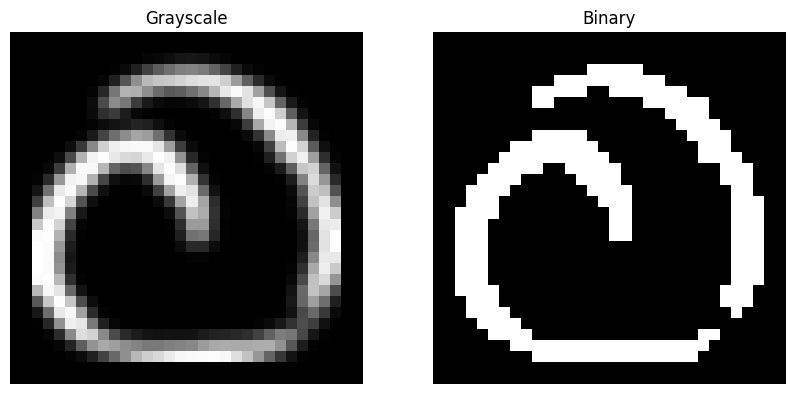

In [3]:
# convert to grayscale and then to binary
# function from lab 3
def show_images(images, titles, cmap=None):
    n = len(images)
    plt.figure(figsize=(5*n, 5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

# Pick one image from class 0
img_path = "train/train/0/103265.png"
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

show_images([gray, binary], ["Grayscale", "Binary"])

In [4]:
# Define a function to center images.
def center_image(image_array):
    # Compute the moments of the image
    moments = cv2.moments(image_array)

    if moments["m00"] == 0:
        return image_array  # Return the original image if there are no moments
    
    # Calculate the center of mass    
    cX = int(moments["m10"] / moments["m00"])
    cY = int(moments["m01"] / moments["m00"])

    # Calculate the shift needed to center the image
    shift_x = image_array.shape[1] // 2 - cX
    shift_y = image_array.shape[0] // 2 - cY

    # Apply the shift
    translation_M = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
    centered_image = cv2.warpAffine(image_array, translation_M, (image_array.shape[1], image_array.shape[0]))

    return centered_image 

Loaded 17000 images, shape: (17000, 32, 32)


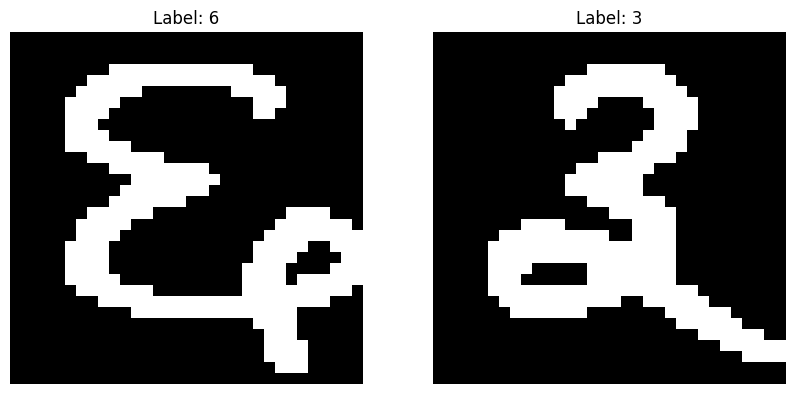

In [5]:
# Convert images to grayscale, then binary, and then center them.
# It might seem weird why we do first centering and then data augmentation, but this ensures that we do not loose information from the images after augmentation.
# If we would not center the images and a digit is close to a border and we then shift this image, we would get an incomplete image in our augmented dataset and we would feed our model incomplete images.
import pandas as pd
import numpy as np

train_df = pd.read_csv("train.csv")

images = []
labels = []

for _, row in train_df.iterrows():
    img_id = row["Id"]
    label = row["Category"]
    path = f"train/train/{label}/{img_id}.png"
    
    img = cv2.imread(path)

    # Warn if the image is not loaded properly
    if img is None:
        print(f"Warning: Could not load image at {path}")
        continue

    # Convert to grayscale, then to binary, and then center the image
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    centered_binary = center_image(binary)

    # Append the centered grayscale image and label to the lists
    images.append(centered_binary)
    labels.append(label)

images = np.array(images)
labels = np.array(labels)

print(f"Loaded {len(images)} images, shape: {images.shape}")
show_images(images[:2], [f"Label: {label}" for label in labels[:2]], cmap='gray')

100%|██████████████████████████████████████████████████████████████████████████| 17000/17000 [00:05<00:00, 3241.78it/s]


Loaded 17000 binary images, shape: (17000, 32, 32)
Loaded 17000 centered binary images, shape: (17000, 32, 32)
Loaded 17000 grayscale images, shape: (17000, 32, 32)
Loaded 17000 centered grayscale images, shape: (17000, 32, 32)
Binary images:


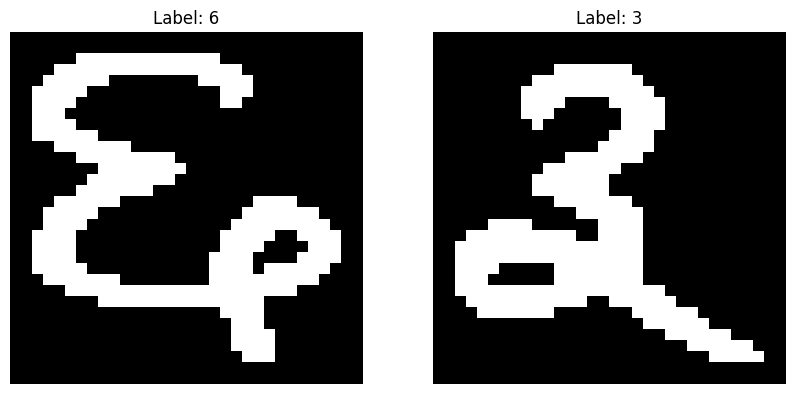

Grayscale images:


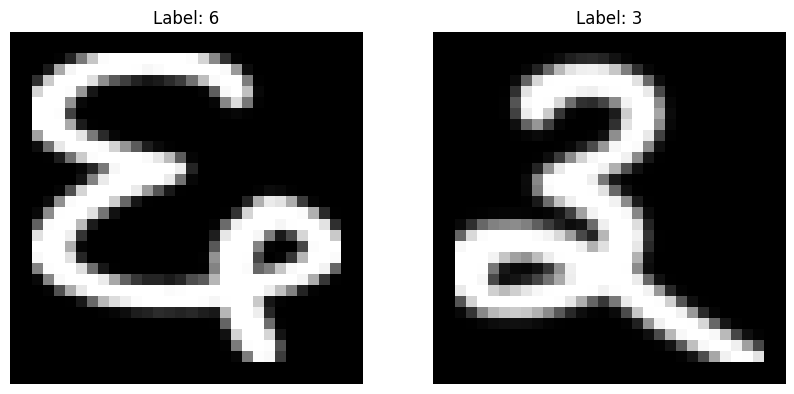

In [6]:
# performance critical
# Build all four image variants in a single pass — no disk writes needed
binary_list, binary_centered_list = [], []
grayscale_list, grayscale_centered_list = [], []
labels = []

for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    img_id = row["Id"]
    label = row["Category"]
    path = f"train/train/{label}/{img_id}.png"

    img = cv2.imread(path)
    if img is None:
        print(f"Warning: Could not load image at {path}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    binary_list.append(binary)
    binary_centered_list.append(center_image(binary))
    grayscale_list.append(gray)
    grayscale_centered_list.append(center_image(gray))
    labels.append(label)

binary_images = np.array(binary_list)
binary_centered_images = np.array(binary_centered_list)
grayscale_images = np.array(grayscale_list)
grayscale_centered_images = np.array(grayscale_centered_list)
labels = np.array(labels)

print(f"Loaded {len(binary_images)} binary images, shape: {binary_images.shape}")
print(f"Loaded {len(binary_centered_images)} centered binary images, shape: {binary_centered_images.shape}")
print(f"Loaded {len(grayscale_images)} grayscale images, shape: {grayscale_images.shape}")
print(f"Loaded {len(grayscale_centered_images)} centered grayscale images, shape: {grayscale_centered_images.shape}")
print('Binary images:')
show_images(binary_images[:2], [f"Label: {label}" for label in labels[:2]], cmap='gray')

print('Grayscale images:')
show_images(grayscale_images[:2], [f"Label: {label}" for label in labels[:2]], cmap='gray')

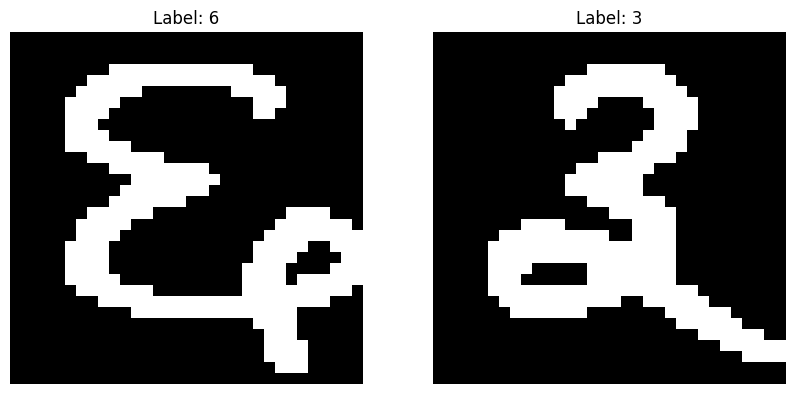

In [7]:
show_images(images[:2], [f"Label: {label}" for label in labels[:2]], cmap='gray')

You only have to execute the following cell once to get the trained images saved on your local computer:

In [8]:
# # Save binary centered images locally
# ## Added  a save block that applies center_image() before writing otherwise nothing was saved to train_binary and the centering was commented out
# # otherwise grayscale_centered_images would not be found
# from pathlib import Path

# output_dir = Path("train_binary")
# output_dir.mkdir(exist_ok=True)

# for _, row in train_df.iterrows():
#     img_id = row["Id"]
#     label = row["Category"]
#     path = f"train/train/{label}/{img_id}.png"
    
#     img = cv2.imread(path)
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#    # centered_binary = center_image(binary)
#     cv2.imwrite(str(output_dir / f"{img_id}.png"), binary)

# print("Done saving binary images")

# # Save centered binary images locally
# output_dir_centered = Path("train_binary_centered")
# output_dir_centered.mkdir(exist_ok=True)

# for _, row in train_df.iterrows():
#     img_id = row["Id"]
#     label = row["Category"]
#     path = f"train/train/{label}/{img_id}.png"

#     img = cv2.imread(path)
#     if img is None:
#         print(f"Warning: Could not load image at {path}")
#         continue
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#     centered_binary = center_image(binary)
#     cv2.imwrite(str(output_dir_centered / f"{img_id}.png"), centered_binary)

# print("Done saving centered binary images")

In [9]:
# # Read in different images
# train_df = pd.read_csv("train.csv")

# # Read in centered binary images
# binary_centered_images = np.array([
#     cv2.imread(f"train_binary_centered/{row['Id']}.png", cv2.IMREAD_GRAYSCALE)
#     for _, row in tqdm(train_df.iterrows(), total=len(train_df))
# ])
# labels = train_df["Category"].values

# # Read in binary images
# binary_images = np.array([
#     cv2.imread(f"train_binary/{row['Id']}.png", cv2.IMREAD_GRAYSCALE)
#     for _, row in tqdm(train_df.iterrows(), total=len(train_df))
# ])

# # Read in centered grayscale images
# grayscale_centered_images = np.array([
#     cv2.imread(f"train_gray_centered/{row['Id']}.png", cv2.IMREAD_GRAYSCALE)
#     for _, row in tqdm(train_df.iterrows(), total=len(train_df))
# ])

# # Read in grayscale images
# grayscale_images = np.array([
#     cv2.imread(f"train_gray/{row['Id']}.png", cv2.IMREAD_GRAYSCALE)
#      for _, row in tqdm(train_df.iterrows(), total=len(train_df))
# ])

# print(f"Loaded {len(binary_images)} binary images, shape: {binary_images.shape}")
# print(f"Loaded {len(binary_centered_images)} centered binary images, shape: {binary_centered_images.shape}")
# print(f"Loaded {len(grayscale_images)} grayscale images, shape: {grayscale_images.shape}")
# print(f"Loaded {len(grayscale_centered_images)} centered grayscale images, shape: {grayscale_centered_images.shape}")
# print('Binary images:')
# show_images(binary_images[:2], [f"Label: {label}" for label in labels[:2]], cmap='gray')

# print('Grayscale images:')
# show_images(grayscale_images[:2], [f"Label: {label}" for label in labels[:2]], cmap='gray')

In [10]:
# train val split:
from sklearn.model_selection import train_test_split
# Flatten images: (N, 32, 32) -> (N, 1024)
X_binary = binary_images.reshape(len(binary_images), -1) / 255.0  # normalize to 0-1
y_binary = labels
X_binary_centered = binary_centered_images.reshape(len(binary_centered_images), -1) / 255.0  # normalize to 0-1
y_binary_centered = labels
X_grayscale = grayscale_images.reshape(len(grayscale_images), -1) / 255.0  # normalize to 0-1
y_grayscale = labels
X_grayscale_centered = grayscale_centered_images.reshape(len(grayscale_centered_images), -1) / 255.0  # normalize to 0-1
y_grayscale_centered = labels

# reshuffle and split into train and validation
X_train_binary, X_val_binary, y_train_binary, y_val_binary = train_test_split(X_binary, y_binary, test_size=0.25, random_state=75, stratify=y_binary)
X_train_binary_centered, X_val_binary_centered, y_train_binary_centered, y_val_binary_centered = train_test_split(X_binary_centered, y_binary_centered, test_size=0.25, random_state=75, stratify=y_binary_centered)
X_train_grayscale, X_val_grayscale, y_train_grayscale, y_val_grayscale = train_test_split(X_grayscale, y_grayscale, test_size=0.25, random_state=75, stratify=y_grayscale)
X_train_grayscale_centered, X_val_grayscale_centered, y_train_grayscale_centered, y_val_grayscale_centered = train_test_split(X_grayscale_centered, y_grayscale_centered, test_size=0.25, random_state=75, stratify=y_grayscale_centered)

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [12]:
# Train SVM on binary images
svm = SVC(kernel="rbf", C=10, gamma=0.01)
svm.fit(X_train_binary, y_train_binary)

# Train SVM on binary centered images
svm_binary_centered = SVC(kernel="rbf", C=10, gamma=0.01)
svm_binary_centered.fit(X_train_binary_centered, y_train_binary_centered)

# Train SVM on grayscale images
svm_grayscale = SVC(kernel="rbf", C=10, gamma=0.01)
svm_grayscale.fit(X_train_grayscale, y_train_grayscale)

# Train SVM on grayscale centered images
svm_grayscale_centered = SVC(kernel="rbf", C=10, gamma=0.01)
svm_grayscale_centered.fit(X_train_grayscale_centered, y_train_grayscale_centered)

# Evaluate
y_pred_binary_svm = svm.predict(X_val_binary)
print(f"SVM val_accuracy on binary images: {accuracy_score(y_val_binary, y_pred_binary_svm):.4f}")

y_pred_binary_centered_svm = svm_binary_centered.predict(X_val_binary_centered)
print(f"SVM val_accuracy on binary centered images: {accuracy_score(y_val_binary_centered, y_pred_binary_centered_svm):.4f}")

y_pred_grayscale_svm = svm_grayscale.predict(X_val_grayscale)
print(f"SVM val_accuracy on grayscale images: {accuracy_score(y_val_grayscale, y_pred_grayscale_svm):.4f}")

y_pred_grayscale_centered_svm = svm_grayscale_centered.predict(X_val_grayscale_centered)
print(f"SVM val_accuracy on grayscale centered images: {accuracy_score(y_val_grayscale_centered, y_pred_grayscale_centered_svm):.4f}")

SVM val_accuracy on binary images: 0.9901
SVM val_accuracy on binary centered images: 0.9904
SVM val_accuracy on grayscale images: 0.9925
SVM val_accuracy on grayscale centered images: 0.9939


Conclusion: best accuracy on grayscale centered images: 0.9939.

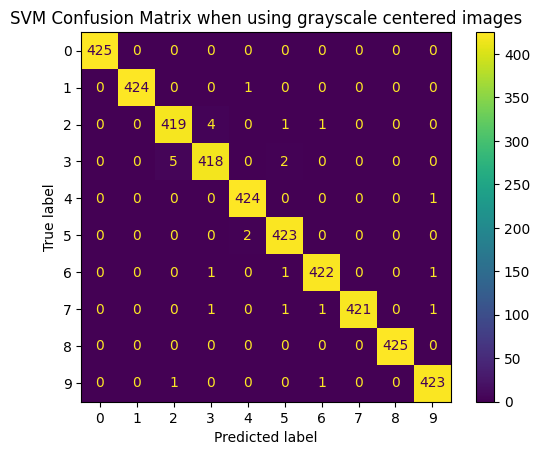

Most confused: true=3, predicted as=2 (5 errors)
Found 5 misclassified 3s predicted as 2


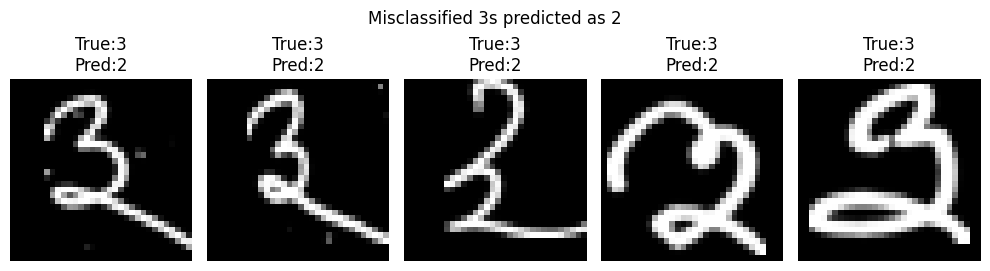

In [13]:
# Confusion matrix for grayscale centered images
cm = confusion_matrix(y_val_grayscale_centered, y_pred_grayscale_centered_svm)
ConfusionMatrixDisplay(cm).plot()
plt.title("SVM Confusion Matrix when using grayscale centered images")
plt.show()

# find the two most confused classes
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
most_confused = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
true_class, pred_class = most_confused
print(f"Most confused: true={true_class}, predicted as={pred_class} ({cm_no_diag[true_class, pred_class]} errors)")

# visualize misclassified images from that pair
mask = (y_val_grayscale_centered == true_class) & (y_pred_grayscale_centered_svm == pred_class)
misclassified_idx = np.where(mask)[0]
print(f"Found {len(misclassified_idx)} misclassified {true_class}s predicted as {pred_class}")

n = min(10, len(misclassified_idx))
plt.figure(figsize=(2*n, 3))
for i, idx in enumerate(misclassified_idx[:n]):
    img = X_val_grayscale_centered[idx].reshape(32, 32)
    plt.subplot(1, n, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True:{y_val_grayscale_centered[idx]}\nPred:{y_pred_grayscale_centered_svm[idx]}")
    plt.axis('off')
plt.suptitle(f"Misclassified {true_class}s predicted as {pred_class}")
plt.tight_layout()
plt.show()

So using grayscale images is actually better than using binary images.

In [14]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {"C": [1, 10, 100], "gamma": [0.001, 0.01, "scale"]}
# grid = GridSearchCV(SVC(kernel="rbf"), param_grid, cv=3, verbose=2)
# grid.fit(X_train_grayscale, y_train_grayscale)
# print(f"Best params: {grid.best_params_}")
# print(f"Best accuracy: {grid.best_score_:.4f}")

In [17]:
def extract_hough_features(images_flat):
    """Expects flat float64 0-1 images of shape (N, 1024)."""
    features = []
    for img_flat in images_flat:
        img_uint8 = (img_flat.reshape(32, 32) * 255).astype(np.uint8)
        img_large = cv2.resize(img_uint8, (128, 128), interpolation=cv2.INTER_LINEAR)
        edges = cv2.Canny(img_large, 30, 100)  # lower threshold = more forgiving

        h, w = edges.shape

        # --- Arc density per quadrant ---
        # Helps distinguish 3/E (arcs on right) from 6/9 (arcs on left)
        q_tl = edges[:h//2, :w//2].mean()
        q_tr = edges[:h//2, w//2:].mean()
        q_bl = edges[h//2:, :w//2].mean()
        q_br = edges[h//2:, w//2:].mean()
        right_arc_ratio  = (q_tr + q_br) / (q_tl + q_bl + 1e-6)
        top_arc_ratio    = (q_tl + q_tr) / (q_bl + q_br + 1e-6)

        # --- Contour-based features (robust to imperfect handwriting) ---
        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        n_contours = len(contours)  # 8 has ~2 loops, 1 has 1, 0 has 1 large one

        # Largest contour: how circular is it? (circularity = 1 for perfect circle)
        # Works for imperfect shapes unlike HoughCircles
        circularity = 0.0
        extent = 0.0
        solidity = 0.0
        if contours:
            largest = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(largest)
            perimeter = cv2.arcLength(largest, closed=True)
            if perimeter > 0:
                circularity = (4 * np.pi * area) / (perimeter ** 2)  # 1.0 = perfect circle
            # Extent: how much of the bounding box is filled
            _, _, bw, bh = cv2.boundingRect(largest)
            if bw * bh > 0:
                extent = area / (bw * bh)
            # Solidity: area vs convex hull area (low = concave shape like 3, E)
            hull = cv2.convexHull(largest)
            hull_area = cv2.contourArea(hull)
            if hull_area > 0:
                solidity = area / hull_area

        # --- Euler number (topology): holes in the shape ---
        # 0, 8 have enclosed regions; 3, 2 do not
        _, thresh = cv2.threshold(img_large, 127, 255, cv2.THRESH_BINARY)
        contours_holes, hierarchy = cv2.findContours(
            thresh, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
        n_holes = 0
        if hierarchy is not None:
            # holes are contours with a parent (hierarchy[0][i][3] != -1)
            n_holes = np.sum(hierarchy[0][:, 3] != -1)

        features.append([
            n_contours, circularity, extent, solidity, n_holes,
            q_tl, q_tr, q_bl, q_br, right_arc_ratio, top_arc_ratio
        ])
    return np.array(features)

In [20]:
from sklearn.preprocessing import StandardScaler
import cv2
import numpy as np
# Extract Hough features
print("Extracting Hough features for grayscale...")
X_train_grayscale_hough = extract_hough_features(X_train_grayscale)
X_val_grayscale_hough   = extract_hough_features(X_val_grayscale)

print("Extracting Hough features for grayscale centered...")
X_train_grayscale_centered_hough = extract_hough_features(X_train_grayscale_centered)
X_val_grayscale_centered_hough   = extract_hough_features(X_val_grayscale_centered)

# Only scale the Hough features, leave pixels as-is
scaler_g = StandardScaler()
X_train_grayscale_hough_scaled = scaler_g.fit_transform(X_train_grayscale_hough)
X_val_grayscale_hough_scaled   = scaler_g.transform(X_val_grayscale_hough)

scaler_gc = StandardScaler()
X_train_grayscale_centered_hough_scaled = scaler_gc.fit_transform(X_train_grayscale_centered_hough)
X_val_grayscale_centered_hough_scaled   = scaler_gc.transform(X_val_grayscale_centered_hough)

# Concatenate unscaled pixels + scaled Hough
X_train_grayscale_combined = np.hstack([X_train_grayscale, X_train_grayscale_hough_scaled])
X_val_grayscale_combined   = np.hstack([X_val_grayscale,   X_val_grayscale_hough_scaled])

X_train_grayscale_centered_combined = np.hstack([X_train_grayscale_centered, X_train_grayscale_centered_hough_scaled])
X_val_grayscale_centered_combined   = np.hstack([X_val_grayscale_centered,   X_val_grayscale_centered_hough_scaled])

# Train SVMs with Hough features added
svm_grayscale_hough = SVC(kernel="rbf", C=10, gamma=0.01)
svm_grayscale_hough.fit(X_train_grayscale_combined, y_train_grayscale)

svm_grayscale_centered_hough = SVC(kernel="rbf", C=10, gamma=0.01)
svm_grayscale_centered_hough.fit(X_train_grayscale_centered_combined, y_train_grayscale_centered)

# Evaluate all four side by side
y_pred_grayscale_svm = svm_grayscale.predict(X_val_grayscale)
y_pred_grayscale_centered_svm = svm_grayscale_centered.predict(X_val_grayscale_centered)
y_pred_grayscale_hough_svm = svm_grayscale_hough.predict(X_val_grayscale_combined)
y_pred_grayscale_centered_hough_svm = svm_grayscale_centered_hough.predict(X_val_grayscale_centered_combined)

print(f"SVM grayscale (pixels only):          {accuracy_score(y_val_grayscale, y_pred_grayscale_svm):.4f}")
print(f"SVM grayscale + Hough:                {accuracy_score(y_val_grayscale, y_pred_grayscale_hough_svm):.4f}")
print(f"SVM grayscale centered (pixels only): {accuracy_score(y_val_grayscale_centered, y_pred_grayscale_centered_svm):.4f}")
print(f"SVM grayscale centered + Hough:       {accuracy_score(y_val_grayscale_centered, y_pred_grayscale_centered_hough_svm):.4f}")

Extracting Hough features for grayscale...
Extracting Hough features for grayscale centered...
SVM grayscale (pixels only):          0.9925
SVM grayscale + Hough:                0.9932
SVM grayscale centered (pixels only): 0.9939
SVM grayscale centered + Hough:       0.9946


Added Hough features
Results: 

SVM grayscale (pixels only):          0.9925
SVM grayscale + Hough:                0.9932
SVM grayscale centered (pixels only): 0.9939
SVM grayscale centered + Hough:       0.9946

In [22]:
# add augmented features without Hough
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Define augmentation
datagen = ImageDataGenerator(
    rotation_range=10,        # rotate up to 10 degrees
    width_shift_range=0.1,    # shift horizontally up to 10%
    height_shift_range=0.1,   # shift vertically up to 10%
    zoom_range=0.1,           # zoom in/out up to 10%
    shear_range=0.1           # slight shear
)


# Reshape back to grayscale centered images for augmentation
X_train = X_train_grayscale_centered
y_train = y_train_grayscale_centered
X_train_img = X_train.reshape(-1, 32, 32, 1)

# Generate 3 batches of augmented data.
X_aug_list = []
y_aug_list = []
batches_generated = 0
batches_to_generate = 3

for X_batch, y_batch in datagen.flow(X_train_img, y_train, batch_size=len(X_train)):
    X_aug_list.append(X_batch.reshape(-1, 1024))  # flatten back
    y_aug_list.append(y_batch)
    batches_generated += 1
    if batches_generated >= batches_to_generate:
        break

# Combine original + augmented
X_combined = np.vstack([X_train, np.vstack(X_aug_list)])
y_combined = np.concatenate([y_train, np.concatenate(y_aug_list)])

print(f"Original: {len(X_train)} | Augmented: {len(X_combined)}")

Original: 12750 | Augmented: 51000


In [24]:
# Retrain SVM
X_val = X_val_grayscale_centered
y_val = y_val_grayscale_centered
aug_svm = SVC(kernel="rbf", C=10, gamma=0.01)
aug_svm.fit(X_combined, y_combined)

y_pred_aug = aug_svm.predict(X_val)
print(f"Augmented SVM val_accuracy: {accuracy_score(y_val, y_pred_aug):.4f}")

Augmented SVM val_accuracy: 0.9962


Before the accuracy was 0.9958 (before changing the rotation range from 0.1 to 10, and adding more augmented data), so this step actually increased accuracy.

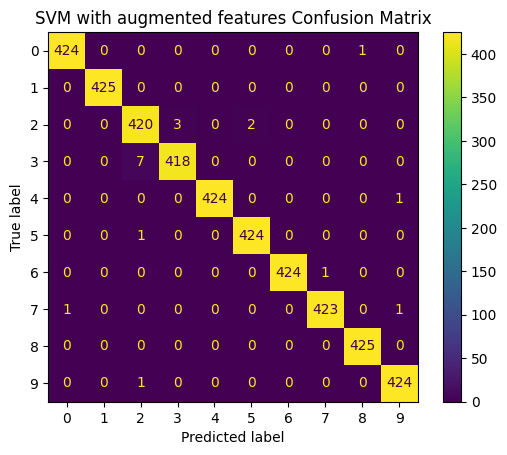

Most confused: true=3, predicted as=2 (7 errors)
Found 7 misclassified 3s predicted as 2


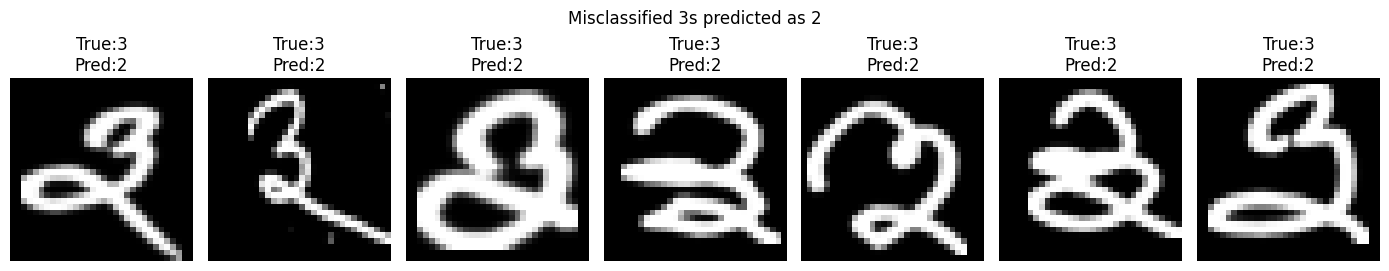

In [22]:
# confusion matrix
cm = confusion_matrix(y_val, y_pred_aug)
ConfusionMatrixDisplay(cm).plot()
plt.title("SVM with augmented features Confusion Matrix")
plt.show()

# find the two most confused classes
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
most_confused = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
true_class, pred_class = most_confused
print(f"Most confused: true={true_class}, predicted as={pred_class} ({cm_no_diag[true_class, pred_class]} errors)")

# visualize misclassified images from that pair
mask = (y_val == true_class) & (y_pred_aug == pred_class)
misclassified_idx = np.where(mask)[0]
print(f"Found {len(misclassified_idx)} misclassified {true_class}s predicted as {pred_class}")

n = min(10, len(misclassified_idx))
plt.figure(figsize=(2*n, 3))
for i, idx in enumerate(misclassified_idx[:n]):
    img = X_val[idx].reshape(32, 32)
    plt.subplot(1, n, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True:{y_val[idx]}\nPred:{y_pred_aug[idx]}")
    plt.axis('off')
plt.suptitle(f"Misclassified {true_class}s predicted as {pred_class}")
plt.tight_layout()
plt.show()

Now try to increase accuracy by adding HOG features.

In [25]:
# Extract Hough features to add them to augmented feature set
print("Extracting Hough features from augmented training data...")
X_combined_hough = extract_hough_features(X_combined)  

# Step 3: scale Hough only, then concatenate
scaler = StandardScaler()
X_combined_hough_scaled = scaler.fit_transform(X_combined_hough)
X_val_hough_scaled = scaler.transform(extract_hough_features(X_val))

X_combined_full = np.hstack([X_combined, X_combined_hough_scaled])
X_val_full = np.hstack([X_val, X_val_hough_scaled])

Extracting Hough features from augmented training data...


In [27]:
# Scale Hough features to add them to augmented val set
from sklearn.preprocessing import StandardScaler

print("Extracting Hough features for validation set...")
X_val_hough = extract_hough_features(X_val)

scaler = StandardScaler()
X_combined_hough_scaled = scaler.fit_transform(X_combined_hough)
X_val_hough_scaled = scaler.transform(X_val_hough)

# Concatenate unscaled pixels + scaled Hough
X_combined_full = np.hstack([X_combined, X_combined_hough_scaled])
X_val_full = np.hstack([X_val, X_val_hough_scaled])

# Train SVM with Hough features added
aug_hough_svm = SVC(kernel="rbf", C=10, gamma=0.01)
aug_hough_svm.fit(X_combined_full, y_combined)

y_pred_aug_hough = aug_hough_svm.predict(X_val_full)

# Compare
print(f"Augmented SVM (pixels only):        {accuracy_score(y_val, y_pred_aug):.4f}")
print(f"Augmented SVM (pixels + Hough):     {accuracy_score(y_val, y_pred_aug_hough):.4f}")

Extracting Hough features for validation set...
Augmented SVM (pixels only):        0.9962
Augmented SVM (pixels + Hough):     0.9965


In [23]:
from skimage.feature import hog

# Reshape back to 2D images for HOG feature extraction
X_train = X_combined.reshape(-1, 32, 32)
X_val = X_val.reshape(-1, 32, 32)

def extract_hog(images):
    features = []
    for img in images:
        fd = hog(img.reshape(32, 32), orientations=9,
                 pixels_per_cell=(4, 4), cells_per_block=(2, 2))
        features.append(fd)
    return np.array(features)

print("Extract HOG features from training data...")
X_train_hog = extract_hog(X_train)
print("Extract HOG features from validation data...")
X_val_hog = extract_hog(X_val)

print(f"HOG feature shape for training data: {X_train_hog.shape}")
print(f"HOG feature shape for validation data: {X_val_hog.shape}")  


Extract HOG features from training data...
Extract HOG features from validation data...
HOG feature shape for training data: (51000, 1764)
HOG feature shape for validation data: (4250, 1764)


In [24]:
print(f"Training SVM on HOG features...")
hog_svm = SVC(kernel="rbf", C=10, gamma=0.01)
hog_svm.fit(X_train_hog, y_combined)
print(f"HOG SVM: {accuracy_score(hog_svm.predict(X_val_hog), y_val):.4f}")

Training SVM on HOG features...
HOG SVM: 0.9965


HOG SVM accuracy: 0.9965

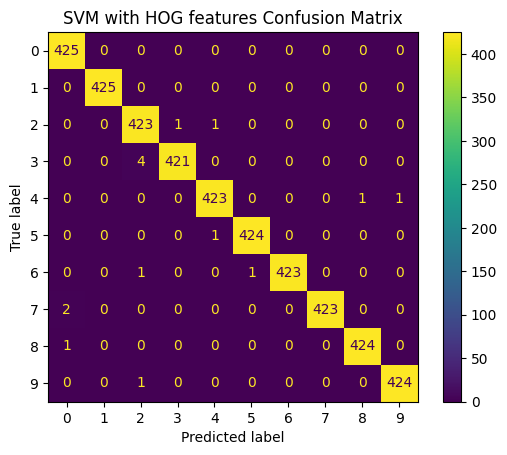

Most confused: true=3, predicted as=2 (4 errors)
Found 4 misclassified 3s predicted as 2


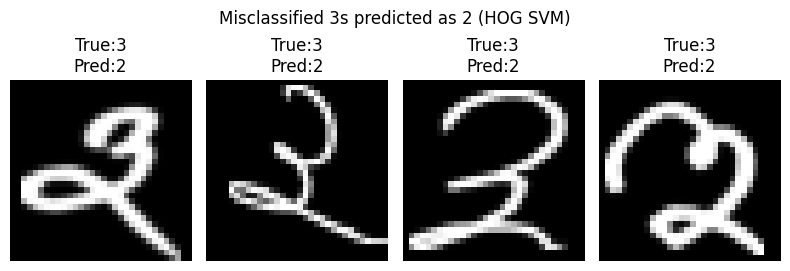

In [25]:
# confusion matrix
cm = confusion_matrix(y_val, hog_svm.predict(X_val_hog))
ConfusionMatrixDisplay(cm).plot()
plt.title("SVM with HOG features Confusion Matrix")
plt.show()

# find the two most confused classes
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
most_confused = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
true_class, pred_class = most_confused
print(f"Most confused: true={true_class}, predicted as={pred_class} ({cm_no_diag[true_class, pred_class]} errors)")     

# visualize misclassified images from that pair
mask = (y_val == true_class) & (hog_svm.predict(X_val_hog) == pred_class)
misclassified_idx = np.where(mask)[0]
print(f"Found {len(misclassified_idx)} misclassified {true_class}s predicted as {pred_class}")  
n = min(10, len(misclassified_idx))
plt.figure(figsize=(2*n, 3))
for i, idx in enumerate(misclassified_idx[:n]):
    img = X_val[idx].reshape(32, 32)
    plt.subplot(1, n, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True:{y_val[idx]}\nPred:{hog_svm.predict(X_val_hog)[idx]}")
    plt.axis('off')
plt.suptitle(f"Misclassified {true_class}s predicted as {pred_class} (HOG SVM)")
plt.tight_layout()
plt.show()


Interestingly, HOG does not cause an increase in performance compared to the increase in performance after adding more augmented data.

In [ ]:
# Apply StandardScaler to HOG features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_hog_scaled = scaler.fit_transform(X_train_hog)
X_val_hog_scaled = scaler.transform(X_val_hog)

# Train SVM on scaled HOG features
print(f"Training SVM on scaled HOG features...")
hog_scaled_svm = SVC(kernel="rbf", C=10, gamma=0.01)
hog_scaled_svm.fit(X_train_hog_scaled, y_combined)
print(f"HOG Scaled SVM: {accuracy_score(hog_scaled_svm.predict(X_val_hog_scaled), y_val):.4f}") 

In [28]:
# Apply skeletonization
def skeletonize_images(image):
    # Binarize the image because skeltonization requires binary images
    img_uint8 = (image * 255).astype(np.uint8) if image.dtype != np.uint8 else image
    _, binary = cv2.threshold(img_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Convert to boolean array
    boolean_image = binary > 0

    # Apply skeletonization
    skeleton = morphology.skeletonize(boolean_image)

    # Convert back to uint8
    skeleton_uint8 = (skeleton * 255).astype(np.uint8)
    return skeleton_uint8

print(f"Skeletonizing {len(X_train)} train images and {len(X_val)} val images...")
X_train_skeleton = np.array([skeletonize_images(img) for img in tqdm(X_train, desc="Skeletonize train")])
X_val_skeleton = np.array([skeletonize_images(img) for img in tqdm(X_val, desc="Skeletonize val")])

Skeletonizing 51000 train images and 4250 val images...



Skeletonize train: 100%|██████████████████████████████████████████████████████| 51000/51000 [00:03<00:00, 14107.65it/s]

Skeletonize val: 100%|██████████████████████████████████████████████████████████| 4250/4250 [00:00<00:00, 21075.51it/s]


In [31]:
# Apply HOG to skeleton images
print("Extract HOG features from skeleton training data...")
X_train_skeleton_hog = extract_hog(X_train_skeleton)
print("Extract HOG features from skeleton validation data...")
X_val_skeleton_hog = extract_hog(X_val_skeleton)
print(f"HOG feature shape for skeleton training data: {X_train_skeleton_hog.shape}")
print(f"HOG feature shape for skeleton validation data: {X_val_skeleton_hog.shape}")

Extract HOG features from skeleton training data...
Extract HOG features from skeleton validation data...
HOG feature shape for skeleton training data: (51000, 1764)
HOG feature shape for skeleton validation data: (4250, 1764)


In [32]:
# Train SVM on skeleton HOG features
print(f"Training SVM on skeleton HOG features...")
skeleton_hog_svm = SVC(kernel="rbf", C=10, gamma=0.01)
skeleton_hog_svm.fit(X_train_skeleton_hog, y_combined)
print(f"SVM on skeleton HOG features: {accuracy_score(skeleton_hog_svm.predict(X_val_skeleton_hog), y_val):.4f}")      

Training SVM on skeleton HOG features...
SVM on skeleton HOG features: 0.9922
